In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#モデルの定義

class discriminator(nn.Module): #識別器
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(784, 512)
    self.fc2 = nn.Linear(512, 1)
    self.activation = nn.LeakyReLU(0.1)

  def forward(self, x):
    x = x.view(-1, 784)
    x = self.activation(self.fc1(x))
    x = self.fc2(x)
    return nn.Sigmoid()(x)


class generator(nn.Module): #生成器
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(128, 1024)
    self.fc2 = nn.Linear(1024, 2048)
    self.fc3 = nn.Linear(2048, 784)
    self.activation = nn.ReLU()

  def forward(self, x):
    x = self.activation(self.fc1(x))
    x = self.activation(self.fc2(x))
    x = self.fc3(x)
    x = x.view(-1, 1, 28, 28)
    return nn.Tanh()(x)


In [3]:
#モデルの学習

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epochs = 30
lr = 2e-4
batch_size = 64
loss = nn.BCELoss()

G = generator().to(device)
D = discriminator().to(device)

G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
D_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

train_set = datasets.MNIST('mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)


for epoch in range(epochs):
    for idx, (imgs, _) in enumerate(train_loader):
        idx += 1

        # 識別器の学習
        real_inputs = imgs.to(device)
        real_outputs = D(real_inputs)
        real_label = torch.ones(real_inputs.shape[0], 1).to(device)

        noise = (torch.rand(real_inputs.shape[0], 128) - 0.5) / 0.5
        noise = noise.to(device)
        fake_inputs = G(noise)
        fake_outputs = D(fake_inputs)
        fake_label = torch.zeros(fake_inputs.shape[0], 1).to(device)

        outputs = torch.cat((real_outputs, fake_outputs), 0)
        targets = torch.cat((real_label, fake_label), 0)

        D_loss = loss(outputs, targets)
        D_optimizer.zero_grad()
        D_loss.backward()
        D_optimizer.step()


        #生成器の学習
        noise = (torch.rand(real_inputs.shape[0], 128)-0.5)/0.5
        noise = noise.to(device)

        fake_inputs = G(noise)
        fake_outputs = D(fake_inputs)
        fake_targets = torch.ones([fake_inputs.shape[0], 1]).to(device)
        G_loss = loss(fake_outputs, fake_targets)
        G_optimizer.zero_grad()
        G_loss.backward()
        G_optimizer.step()

        if idx % 100 == 0 or idx == len(train_loader):
            print('Epoch {} Iteration {}: discriminator_loss {:.3f} generator_loss {:.3f}'.format(epoch, idx, D_loss.item(), G_loss.item()))


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.69MB/s]


Epoch 0 Iteration 100: discriminator_loss 0.713 generator_loss 0.802
Epoch 0 Iteration 200: discriminator_loss 0.653 generator_loss 0.783
Epoch 0 Iteration 300: discriminator_loss 0.671 generator_loss 0.754
Epoch 0 Iteration 400: discriminator_loss 0.666 generator_loss 0.743
Epoch 0 Iteration 500: discriminator_loss 0.644 generator_loss 0.763
Epoch 0 Iteration 600: discriminator_loss 0.565 generator_loss 0.887
Epoch 0 Iteration 700: discriminator_loss 0.503 generator_loss 0.949
Epoch 0 Iteration 800: discriminator_loss 0.491 generator_loss 0.908
Epoch 0 Iteration 900: discriminator_loss 0.463 generator_loss 1.088
Epoch 0 Iteration 938: discriminator_loss 0.381 generator_loss 1.228
Epoch 1 Iteration 100: discriminator_loss 0.452 generator_loss 1.211
Epoch 1 Iteration 200: discriminator_loss 0.433 generator_loss 1.212
Epoch 1 Iteration 300: discriminator_loss 0.374 generator_loss 1.465
Epoch 1 Iteration 400: discriminator_loss 0.390 generator_loss 1.642
Epoch 1 Iteration 500: discriminat

Real Image:


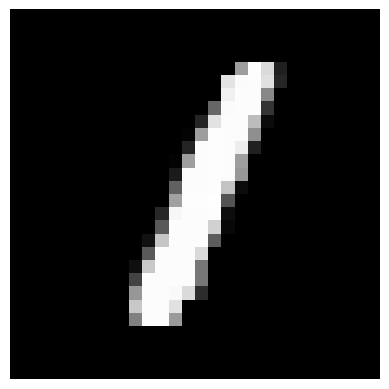

Fake Image:


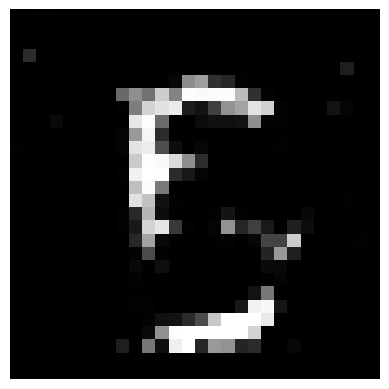

In [4]:
#画像生成

sample_loader = DataLoader(train_set, batch_size=1, shuffle=True)

for real_img, _ in sample_loader:
    real_img = real_img.to(device)

    print("Real Image:")
    plt.imshow(real_img[0][0].cpu().numpy(), cmap='gray')
    plt.axis("off")
    plt.show()

    noise = torch.randn(1, 128).to(device)
    fake_img = G(noise)

    print("Fake Image:")
    fake_img = (fake_img + 1) / 2
    plt.imshow(fake_img[0][0].cpu().detach().numpy(), cmap='gray')
    plt.axis("off")
    plt.show()
    break